**Этот блокнот является упражнением из курса [Компьютерное зрение](https://www.kaggle.com/learn/computer-vision). Вы можете ознакомиться с руководством по [этой ссылке](https://www.kaggle.com/ryanholbrook/custom-convnets).**

---


# Введение #

В этих упражнениях вы построите собственную свёрточную сеть, производительность которой будет конкурировать с моделью VGG16 из Урока 1.

Начните с выполнения ячейки кода ниже.

In [1]:
# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


2026-06-23 17:37:46.753753: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 17:37:47.067615: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-23 17:37:47.067672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-23 17:37:47.080299: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-23 17:37:47.127045: I tensorflow/core/platform/cpu_feature_guar

NotFoundError: Could not find directory ../input/car-or-truck/train

# Проектирование свёрточной сети #

Давайте спроектируем свёрточную сеть с блочной архитектурой, как мы видели в руководстве. Модель из примера имела три блока, каждый с одним свёрточным слоем. Её производительность на задаче «Автомобиль или Грузовик» была приемлемой, но далеко от того, что могла достичь предобученная VGG16. Возможно, нашей простой сети не хватает способности извлекать достаточно сложные признаки. Мы могли бы попробовать улучшить модель, добавив больше блоков или увеличив количество свёрточных слоёв в существующих блоках.

Давайте выберем второй подход. Мы сохраним структуру из трёх блоков, но увеличим количество слоёв `Conv2D` во втором блоке до двух, а в третьем блоке — до трёх.

<figure>
<!-- <img src="./img/2-convmodel-2.png" width="250" alt="Диаграмма свёрточной модели."> -->
<img src="./img/Vko6nCK.png" width="250" alt="Диаграмма свёрточной модели.">
</figure>

# 1) Определение модели #

Основываясь на диаграмме выше, завершите модель, определив слои третьего блока.

In [3]:
# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


Found 5117 files belonging to 2 classes.


2026-06-23 17:38:55.127836: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 17:38:55.254854: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 17:38:55.254922: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 17:38:55.260423: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-23 17:38:55.260487: I external/local_xla/xla/stream_executor

Found 5051 files belonging to 2 classes.


In [4]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # Block One
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same',
                  input_shape=[128, 128, 3]),
    layers.MaxPool2D(),

    # Block Two
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Three
    # YOUR CODE HERE
    layers.Conv2D(filters=128, kernel_size=3,
                  activation='relu', padding='same'),
    layers.Conv2D(filters=128, kernel_size=3,
                  activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Head
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])


# 2) Компиляция #

Чтобы подготовиться к обучению, скомпилируйте модель с подходящей функцией потерь и метрикой точности для набора данных «Автомобиль или Грузовик».

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.01),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

Наконец, давайте проверим производительность этой новой модели. Сначала выполните эту ячейку, чтобы обучить модель на обучающем наборе.

In [6]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=50,
)

Epoch 1/50


2026-06-23 17:39:38.256926: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-06-23 17:39:40.414484: I external/local_xla/xla/service/service.cc:168] XLA service 0x797eb27e93c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-23 17:39:40.414524: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-06-23 17:39:40.430356: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782236380.537567     342 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 [==============================] - 23s 218ms/step - loss: 0.6774 - binary_accuracy: 0.5738 - val_loss: 0.6651 - val_binary_accuracy: 0.5848
Epoch 2/50
80/80 [==============================] - 6s 79ms/step - loss: 0.6647 - binary_accuracy: 0.5937 - val_loss: 0.6557 - val_binary_accuracy: 0.6072
Epoch 3/50
80/80 [==============================] - 6s 76ms/step - loss: 0.6599 - binary_accuracy: 0.6070 - val_loss: 0.6507 - val_binary_accuracy: 0.6351
Epoch 4/50
80/80 [==============================] - 6s 75ms/step - loss: 0.6515 - binary_accuracy: 0.6181 - val_loss: 0.6403 - val_binary_accuracy: 0.6234
Epoch 5/50
80/80 [==============================] - 6s 74ms/step - loss: 0.6391 - binary_accuracy: 0.6312 - val_loss: 0.6282 - val_binary_accuracy: 0.6397
Epoch 6/50
80/80 [==============================] - 5s 68ms/step - loss: 0.6180 - binary_accuracy: 0.6582 - val_loss: 0.6174 - val_binary_accuracy: 0.6508
Epoch 7/50
80/80 [==============================] - 6s 76ms/step - loss: 0.6040

А теперь выполните ячейку ниже, чтобы построить графики потерь и метрик для этого процесса обучения.

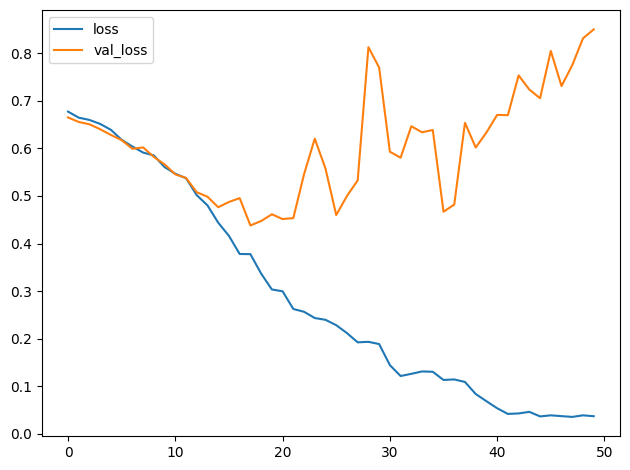

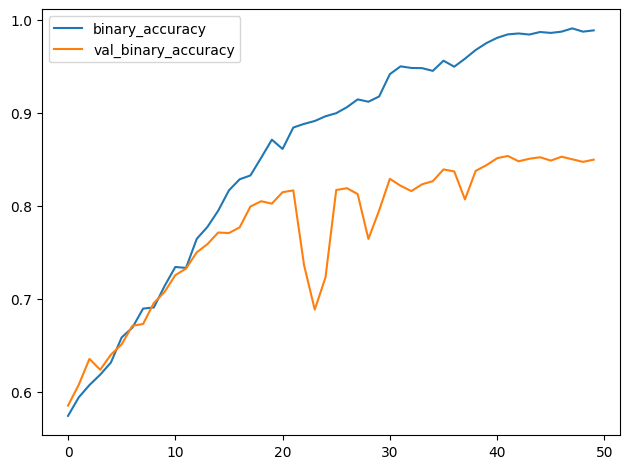

In [7]:
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

# 3) Обучение модели #

Как бы вы интерпретировали эти кривые обучения? Улучшилась ли эта модель по сравнению с моделью из руководства?

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_3.check()

# Заключение #

Эти упражнения показали вам, как проектировать собственную свёрточную сеть для решения конкретной задачи классификации. Хотя в наши дни большинство моделей строятся на основе предобученной базы, в определённых обстоятельствах небольшая собственная свёрточная сеть всё ещё может быть предпочтительнее — например, при работе с небольшим или нестандартным набором данных, или когда вычислительные ресурсы сильно ограничены. Как вы видели здесь, для некоторых задач они могут работать не хуже предобученной модели.

# Продолжайте обучение #

Переходите к [**Уроку 6**](https://www.kaggle.com/ryanholbrook/data-augmentation), где вы изучите широко используемую технику, которая может улучшить ваши обучающие данные: **аугментацию данных**.

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*